# IQP-FinanceSynth: Tutorial & Results

This notebook generates the demo fraud dataset, trains the IQP generator
and the classical baselines, evaluates synthetic data quality, and runs
the sample complexity analysis referenced in the README.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # so `import iqp_finance` works from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from iqp_finance import (
    FinancialDataPreprocessor,
    IQPFinanceGenerator,
    SyntheticEvaluator,
    BernoulliBaseline,
    SampleComplexityAnalyzer,
)
from examples.fraud_detection import generate_demo_fraud_data

np.random.seed(0)

In [2]:
df = generate_demo_fraud_data(n_normal=500, n_fraud=50, random_seed=42)
print(df.shape)
print(df["label"].value_counts())
df.head()

(550, 9)
label
0    500
1     50
Name: count, dtype: int64


,amount,hour_of_day,days_since_last,merchant_risk,card_age_months,n_transactions_24h,distance_from_home,velocity_score,label
0,347.603959,19.0,0.983637,0.108574,99.0,0.0,6.425046,0.126130,0
1,75.301475,12.0,4.811817,0.107066,10.0,1.0,2.391409,0.269807,0
2,7.685870,12.0,5.186997,0.178564,32.0,0.0,0.097097,0.420326,0
3,214.491738,10.0,1.081040,0.133953,68.0,4.0,27.253162,0.233548,0
4,120.545455,1.0,2.306097,0.795530,7.0,10.0,240.433274,0.572784,1


# Step 1: Preprocess (binarize) the financial features

FinancialDataPreprocessor Summary
  Method          : quantile
  n_qubits        : 16
  features used   : 8
  bits/feature    : 2
  total bits used : 16
  feature names   : ['amount', 'hour_of_day', 'days_since_last', 'merchant_risk', 'card_age_months', 'n_transactions_24h', 'distance_from_home', 'velocity_score']


/opt/miniconda3/envs/qml_m1/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


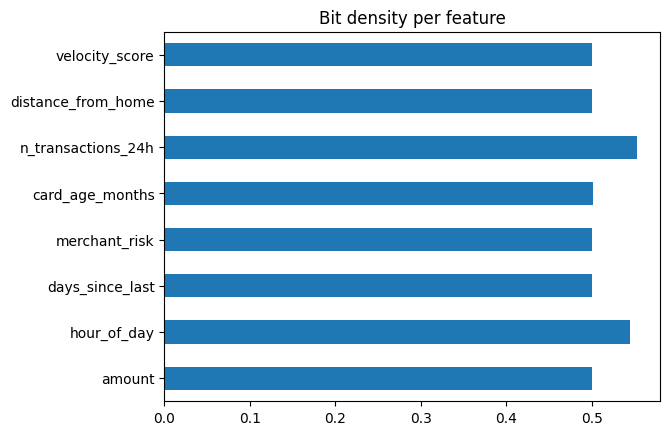

In [3]:
feature_cols = [c for c in df.columns if c != "label"]
X_raw = df[feature_cols]
y = df["label"].values

preprocessor = FinancialDataPreprocessor(
    n_qubits=16, binarize_method="quantile", n_quantiles=4
)
X_binary, feature_map = preprocessor.fit_transform(X_raw)
print(preprocessor.summary())

densities = preprocessor.get_density_per_feature(X_binary)
pd.Series(densities).plot(kind="barh", title="Bit density per feature")
plt.show()

## Step 2: Train the classical baseline (fast — no quantum simulation)

In [4]:
bernoulli = BernoulliBaseline(random_seed=42)
bernoulli.fit(X_binary, y)
X_bern, y_bern = bernoulli.sample(n_samples=200)

## Step 3: Train the IQP generator

Note: this trains one circuit per class and can take a while depending on
`n_steps`. Start small (`n_steps=200`) to sanity-check before running the
full 1000-step training used for final results.

In [5]:
generator = IQPFinanceGenerator(
    n_qubits=16, local_gates=3, sigma=3.0, lr=0.001,
    n_steps=1000, random_seed=42, verbose=True,
)
generator.fit(X_binary, y)
X_synth, y_synth = generator.sample(n_samples=200)

IQP Finance Generator — Training Configuration
  n_qubits        : 16
  local_gates k   : 3
  n_gates (params): 696
  sigma           : 3.0
  lr              : 0.001
  n_steps         : 1000
  classes         : [0 1]

Training Class 0 | n=500 samples


Training Progress: 100%|██████████| 1000/1000 [00:28<00:00, 35.10it/s, loss=-0.000497, elapsed time=0.03, total time=29.4]


Training has not converged after 1000 steps
  ✓ Class 0 trained | final_loss=None

Training Class 1 | n=50 samples


Training Progress: 100%|██████████| 1000/1000 [00:22<00:00, 45.05it/s, loss=0.103321, elapsed time=0.02, total time=22.4]


Training has not converged after 1000 steps
  ✓ Class 1 trained | final_loss=None



## Step 4: Evaluate synthetic data quality — IQP vs. Bernoulli

In [6]:
evaluator = SyntheticEvaluator(sigma=3.0)

results_iqp = evaluator.evaluate(X_binary, X_synth, y, y_synth, feature_names=feature_cols)
results_bern = evaluator.evaluate(X_binary, X_bern, y, y_bern, feature_names=feature_cols)

print("IQP:"); evaluator.print_summary(results_iqp)
print("\nBernoulli:"); evaluator.print_summary(results_bern)

IQP:

  IQP Synthetic Data — Evaluation Summary
  Overall MMD²          : 0.001997

  Per-Class MMD²:
    Class 0            : 0.000000 ← good
    Class 1            : 0.122759

  Correlation Similarity: 0.6449  (1.0=perfect)

  Downstream Task (TSTR):
    TRTR AUC (real→real) : 1.0
    TSTR AUC (syn→real)  : 0.9964

  Class Balance:
    Class 0: real=500  synthetic=182
    Class 1: real=50  synthetic=18


Bernoulli:

  IQP Synthetic Data — Evaluation Summary
  Overall MMD²          : 0.000000

  Per-Class MMD²:
    Class 0            : 0.000000 ← good
    Class 1            : 0.000000 ← good

  Correlation Similarity: 0.6945  (1.0=perfect)

  Downstream Task (TSTR):
    TRTR AUC (real→real) : 1.0
    TSTR AUC (syn→real)  : 1.0

  Class Balance:
    Class 0: real=500  synthetic=181
    Class 1: real=50  synthetic=19



In [7]:
comparison = pd.DataFrame({
    "IQP": {
        "MMD²": results_iqp["mmd2_overall"],
        "Correlation similarity": results_iqp["correlation_similarity"],
        "TSTR AUC": results_iqp["tstr"].get("tstr_auc", np.nan),
    },
    "Bernoulli": {
        "MMD²": results_bern["mmd2_overall"],
        "Correlation similarity": results_bern["correlation_similarity"],
        "TSTR AUC": results_bern["tstr"].get("tstr_auc", np.nan),
    },
})
comparison

,IQP,Bernoulli
MMD²,0.001997,0.000000
Correlation similarity,0.644870,0.694476
TSTR AUC,0.996400,1.000000


Saved evaluation plot to: ../fraud_evaluation.png


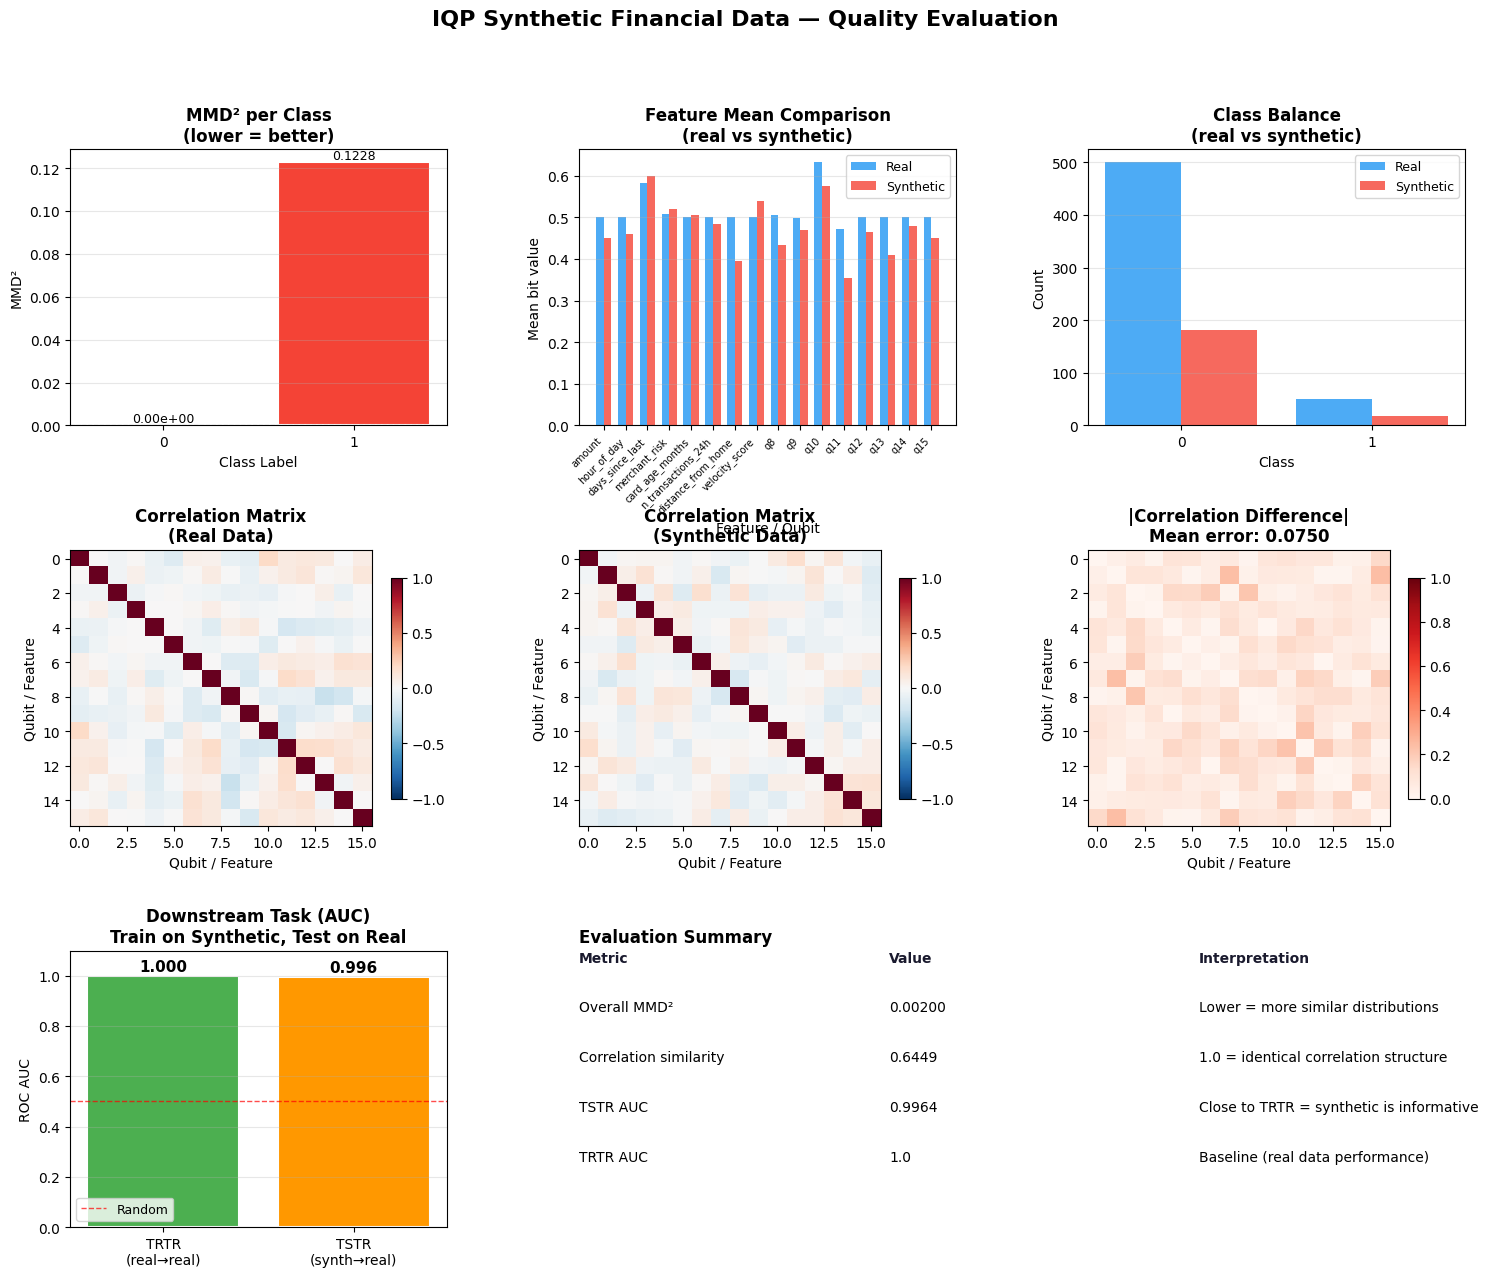

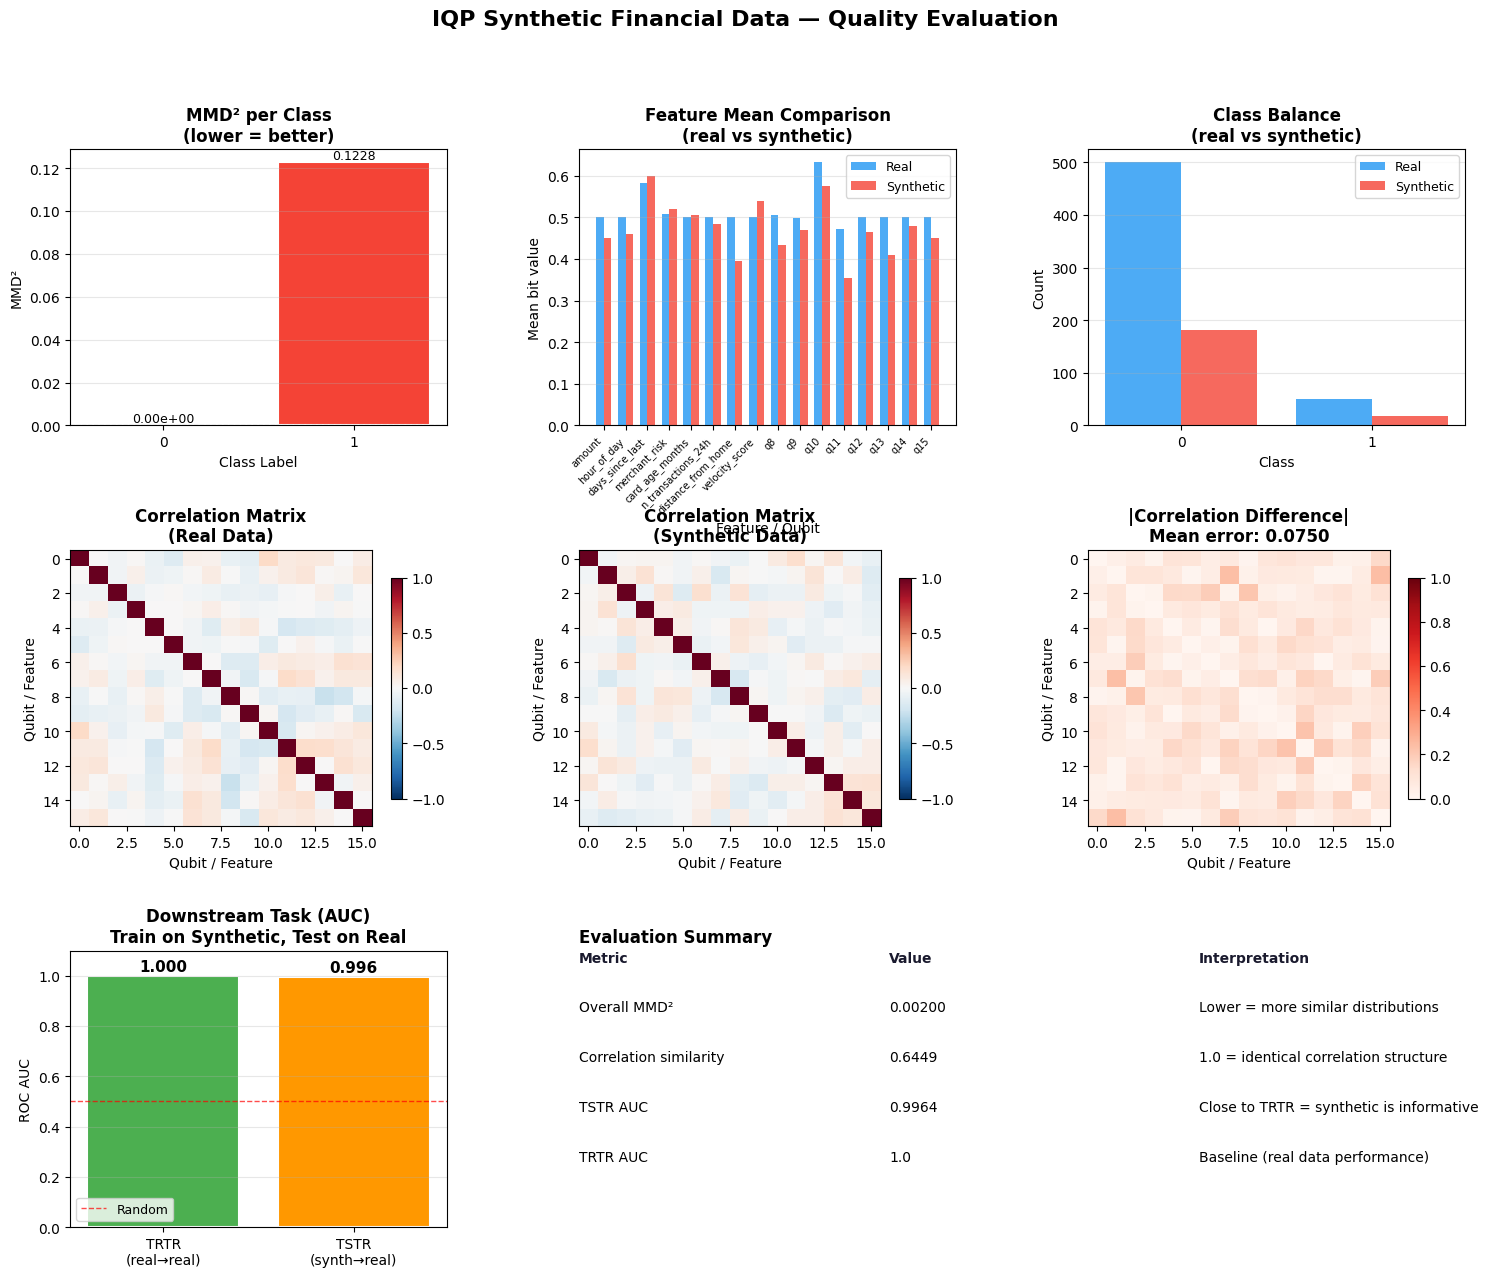

In [8]:
evaluator.plot_results(
    results_iqp, X_binary, X_synth, y, y_synth,
    feature_names=feature_cols,
    save_path="../fraud_evaluation.png",
)

## Step 5: Sample complexity analysis

This is the analysis behind the README's "how much data do you need" claim.
`n_seeds` controls how many random subsamples are averaged per size —
keep this small (2–3) for a quick run; increase for a more reliable curve.

Sample Complexity Analysis
  dataset_sizes : [10, 25, 50, 100, 150, 200]
  n_seeds       : 3
  ratio_thresh  : 1.5
  n_max         : 200

=== n = 10 ===


Training Progress: 100%|██████████| 500/500 [00:09<00:00, 52.42it/s, loss=0.009315, elapsed time=0.02, total time=9.76] 


Training has not converged after 500 steps
  Class 0 | seed 1/3 | MMD²=0.00685


Training Progress: 100%|██████████| 500/500 [00:09<00:00, 51.05it/s, loss=-0.029619, elapsed time=0.02, total time=10]  


Training has not converged after 500 steps
  Class 0 | seed 2/3 | MMD²=0.01632


...

Training has not converged after 500 steps
  Class 0 | seed 1/3 | MMD²=0.00017


Training Progress: 100%|██████████| 500/500 [00:10<00:00, 47.35it/s, loss=-0.000459, elapsed time=0.02, total time=10.8]


Training has not converged after 500 steps
  Class 0 | seed 2/3 | MMD²=0.00083


Training Progress: 100%|██████████| 500/500 [00:11<00:00, 42.89it/s, loss=-0.000311, elapsed time=0.02, total time=11.9]


Training has not converged after 500 steps
  Class 0 | seed 3/3 | MMD²=0.00053
  → Class 0 | mean=0.00051 ± 0.00027

  Class 1: not enough samples, skipping.

--- Minimum Sufficient Dataset Size ---
  Class 0: n = 150  (ratio=1.19x  MMD²=0.00060 vs 0.00051 at n=200)
  Class 1: no sufficient n found in range


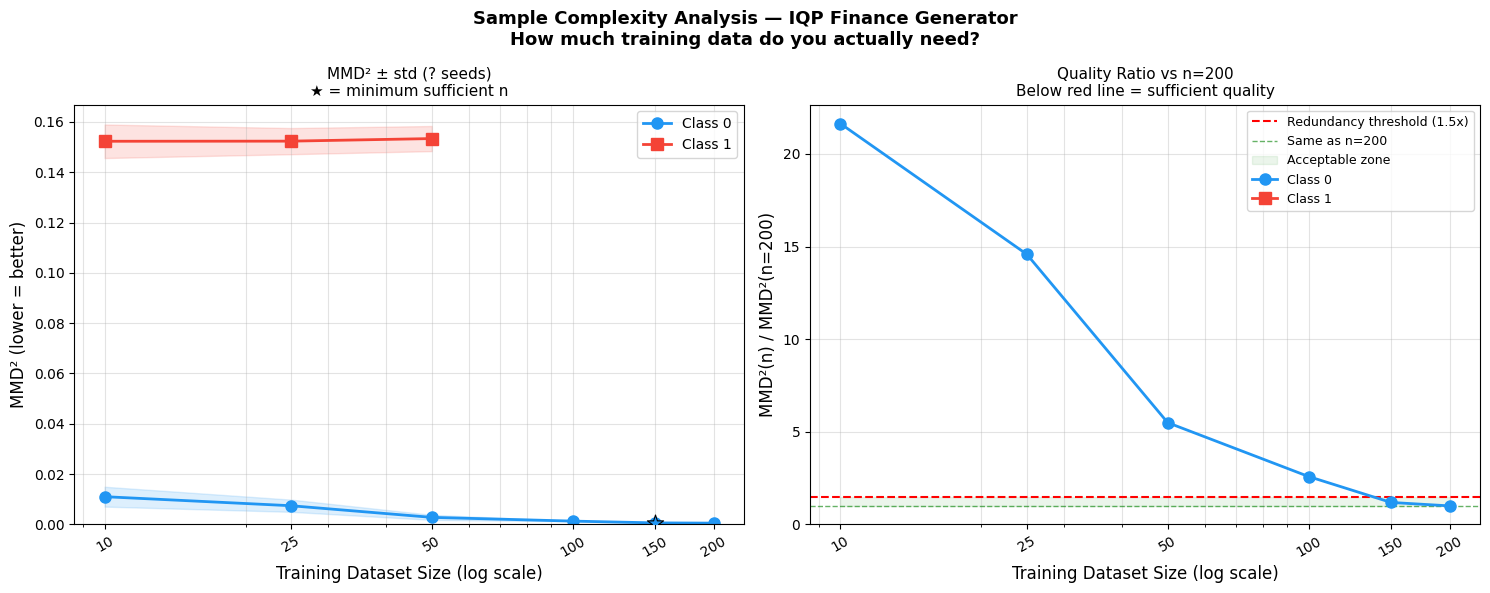

{np.int64(0): 150, np.int64(1): None}

In [9]:
analyzer = SampleComplexityAnalyzer(
    dataset_sizes=[10, 25, 50, 100, 150, 200],  # capped at your fraud class size (50)
    n_seeds=3,
    ratio_threshold=1.5,
    sigma=3.0,
)

sc_results = analyzer.run(
    X_binary, y,
    generator_config={"local_gates": 3, "lr": 0.001, "n_steps": 500, "verbose": False},
)
analyzer.plot(sc_results, save_path="../sample_complexity.png")
analyzer.get_minimum_n(sc_results)